# Task 1: Write a Python code that load the data into your program. Name the dataset as “review_data.csv”

[nltk_data] Downloading package punkt to /Users/akosua/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/akosua/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/akosua/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Top 20 Most Common Words: [('like', 56384), ('would', 41601), ('yeah', 41074), ('get', 38668), ('people', 36969), ('one', 34156), ('know', 29567), ('well', 29552), ('think', 25882), ('make', 25416), ('right', 24816), ('good', 24414), ('time', 22199), ('game', 21507), ('really', 19539), ('sure', 19436), ('need', 19019), ('thing', 18722), ('yes', 17819), ('see', 17741)]


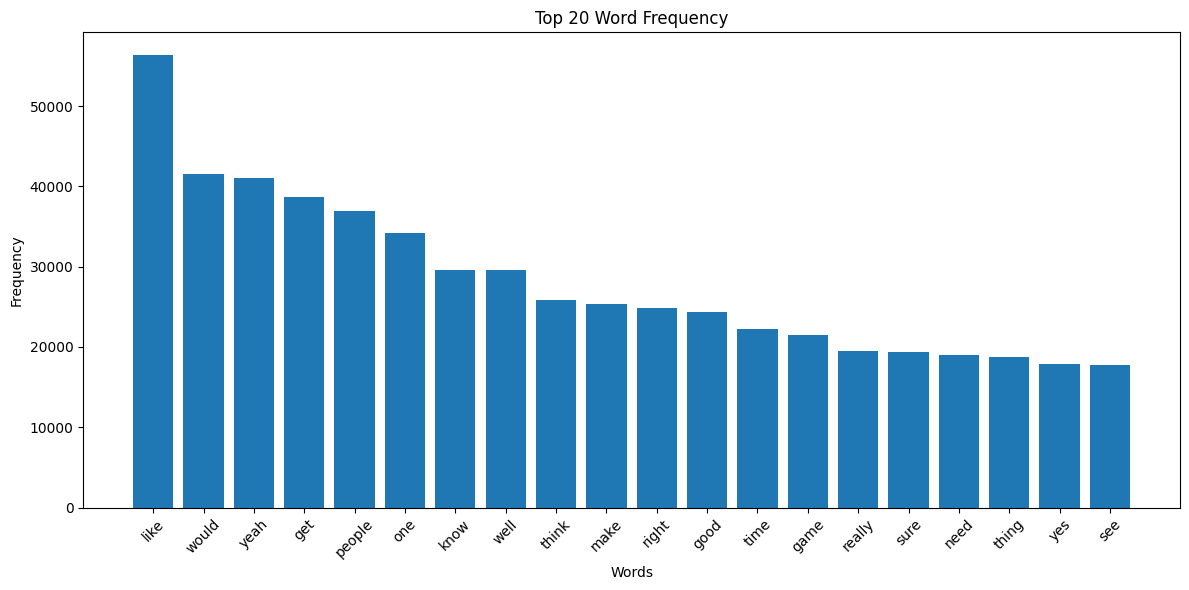

In [1]:
import os
import zipfile
import pandas as pd
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer
from collections import Counter
import matplotlib.pyplot as plt

nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")

csv_path = "dataset.csv" 

df = pd.read_csv(csv_path)

df.rename(columns={"comment": "review", "author": "author"}, inplace=True)


df["review"] = df["review"].astype(str)

stop_words = set(stopwords.words("english"))

def remove_stopwords(text):
    if not isinstance(text, str):
        text = str(text)
    words = word_tokenize(text.lower())
    filtered = [w for w in words if w.isalpha() and w not in stop_words]
    return " ".join(filtered)

df["data_without_stop"] = df["review"].apply(remove_stopwords)
df.to_csv("data_without_stop.csv", index=False)


def remove_numbers(text):
    if not isinstance(text, str):
        text = str(text)
    return re.sub(r"\d+", "", text)

df["new_without_numbers"] = df["data_without_stop"].apply(remove_numbers)
df.to_csv("new_without_numbers.csv", index=False)


lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    if not isinstance(text, str):
        text = str(text)
    tokens = word_tokenize(text)
    lemmas = [lemmatizer.lemmatize(w) for w in tokens]
    return " ".join(lemmas)

df["lemmatized"] = df["new_without_numbers"].apply(lemmatize_text)
df.to_csv("lemmatized_reviews.csv", index=False)


vectorizer = TfidfVectorizer(max_features=2000)
tfidf_matrix = vectorizer.fit_transform(df["lemmatized"])
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=vectorizer.get_feature_names_out())
tfidf_df.to_csv("tfidf_vectors.csv", index=False)


all_words = " ".join(df["lemmatized"]).split()
word_counts = Counter(all_words)

top20_words = word_counts.most_common(20)
print("Top 20 Most Common Words:", top20_words)

words = [w for w, _ in top20_words]
counts = [c for _, c in top20_words]


plt.figure(figsize=(12, 6))
plt.bar(words, counts)
plt.title("Top 20 Word Frequency")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



In [ ]:

df["lemmatized"] = df["new_without_numbers"].apply(lemmatize_text)
df.to_csv("lemmatized_reviews.csv", index=False)

vectorizer = TfidfVectorizer(max_features=2000)
tfidf_matrix = vectorizer.fit_transform(df["lemmatized"])
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=vectorizer.get_feature_names_out())
tfidf_df.to_csv("tfidf_vectors.csv", index=False)


all_words = " ".join(df["lemmatized"]).split()
word_counts = Counter(all_words)

top20_words = word_counts.most_common(20)
print("Top 20 Most Common Words:", top20_words)

words = [w for w, _ in top20_words]
counts = [c for _, c in top20_words]


plt.figure(figsize=(12, 6))
plt.bar(words, counts)
plt.title("Top 20 Word Frequency")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
